# Cancer Risk EDA

Exploratory analysis of `cancer data.csv`. The goal is to understand the patients, the `Level` target (Low / Medium / High), and which scores look useful before training.

This notebook does **not** train a model. Training is in `train.py` / `main.ipynb`. The API is in `app.py`.

The target is a risk label, not a medical diagnosis.

## 1. Load the data

In [1]:
import warnings

import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns

from eda import (
    FIGURES_DIR,
    ID_COLUMNS,
    KEY_FEATURES,
    LEVEL_COLORS,
    LEVEL_ORDER,
    TARGET,
    load_data,
    prepare_xy,
    save_fig,
)

warnings.filterwarnings("ignore")
plt.rcParams["font.family"] = "DejaVu Sans"
sns.set_theme(style="whitegrid", context="notebook")
FIGURES_DIR.mkdir(parents=True, exist_ok=True)

df = load_data()
X, y, feature_cols = prepare_xy(df)
df.head()

,index,Patient Id,Age,Gender,Air Pollution,Alcohol use,Dust Allergy,OccuPational Hazards,Genetic Risk,chronic Lung Disease,...,Fatigue,Weight Loss,Shortness of Breath,Wheezing,Swallowing Difficulty,Clubbing of Finger Nails,Frequent Cold,Dry Cough,Snoring,Level
0,0,P1,33,1,2,4,5,4,3,2,...,3,4,2,2,3,1,2,3,4,Low
1,1,P10,17,1,3,1,5,3,4,2,...,1,3,7,8,6,2,1,7,2,Medium
2,2,P100,35,1,4,5,6,5,5,4,...,8,7,9,2,1,4,6,7,2,High
3,3,P1000,37,1,7,7,7,7,6,7,...,4,2,3,1,4,5,6,7,5,High
4,4,P101,46,1,6,8,7,7,7,6,...,3,2,4,1,4,2,4,2,3,High


Each row is one patient. Most columns are ordinal scores for lifestyle, environmental exposure, medical history, and symptoms. `Level` is the cancer-risk class.

`index` and `Patient Id` identify the person. They are not risk factors, so they are dropped before modeling.

## 2. Dataset quality

In [2]:
print(f"Rows: {df.shape[0]}, Columns: {df.shape[1]}")
print(f"Missing values: {df.isnull().sum().sum()}")
print(f"Duplicate rows: {df.duplicated().sum()}")
print(f"Unique patients: {df['Patient Id'].nunique()}")
print(f"Modeling features: {len(feature_cols)}")
print(f"Unique feature profiles: {X.drop_duplicates().shape[0]}")
print(f"Profiles with more than one label: {(df.groupby(feature_cols, observed=False)[TARGET].nunique() > 1).sum()}")
print()
print("Class balance:")
print(df[TARGET].value_counts().reindex(LEVEL_ORDER))
print()
print("Column types:")
print(df.dtypes)

Rows: 1000, Columns: 26
Missing values: 0
Duplicate rows: 0
Unique patients: 1000
Modeling features: 23
Unique feature profiles: 152
Profiles with more than one label: 0

Class balance:
Level
Low       303
Medium    332
High      365
Name: count, dtype: int64

Column types:
index                       int64
Patient Id                    str
Age                         int64
Gender                      int64
Air Pollution               int64
Alcohol use                 int64
Dust Allergy                int64
OccuPational Hazards        int64
Genetic Risk                int64
chronic Lung Disease        int64
Balanced Diet               int64
Obesity                     int64
Smoking                     int64
Passive Smoker              int64
Chest Pain                  int64
Coughing of Blood           int64
Fatigue                     int64
Weight Loss                 int64
Shortness of Breath         int64
Wheezing                    int64
Swallowing Difficulty       int64
Clubbing of

In [3]:
df[feature_cols].describe().T

,count,mean,std,min,25%,50%,75%,max
Age,1000.0,37.174,12.005493,14.0,27.75,36.0,45.0,73.0
Gender,1000.0,1.402,0.490547,1.0,1.00,1.0,2.0,2.0
Air Pollution,1000.0,3.840,2.030400,1.0,2.00,3.0,6.0,8.0
Alcohol use,1000.0,4.563,2.620477,1.0,2.00,5.0,7.0,8.0
Dust Allergy,1000.0,5.165,1.980833,1.0,4.00,6.0,7.0,8.0
OccuPational Hazards,1000.0,4.840,2.107805,1.0,3.00,5.0,7.0,8.0
Genetic Risk,1000.0,4.580,2.126999,1.0,2.00,5.0,7.0,7.0
chronic Lung Disease,1000.0,4.380,1.848518,1.0,3.00,4.0,6.0,7.0
Balanced Diet,1000.0,4.491,2.135528,1.0,2.00,4.0,7.0,7.0
Obesity,1000.0,4.465,2.124921,1.0,3.00,4.0,7.0,7.0


**What this tells us**

- 1,000 unique patients and no missing values, so no imputation is required.
- The three classes are fairly balanced: High 365 (36.5%), Medium 332 (33.2%), Low 303 (30.3%). A naive model that always predicts High would only be about 36.5% accurate.
- Age ranges from 14 to 73. Almost every other feature is a 1-9 style score, so they can stay numeric.
- There are only **152 unique feature profiles**. Many patients share the same scores, and each profile has one label. That is why a later model can score near 100% on this file. It does not mean the same accuracy would hold on new hospital data.

## 3. Risk-level counts

High risk is the largest group, but not by a large margin. The classes are close enough that accuracy is usable, but we should still report precision, recall, and F1 later so one class cannot hide errors.

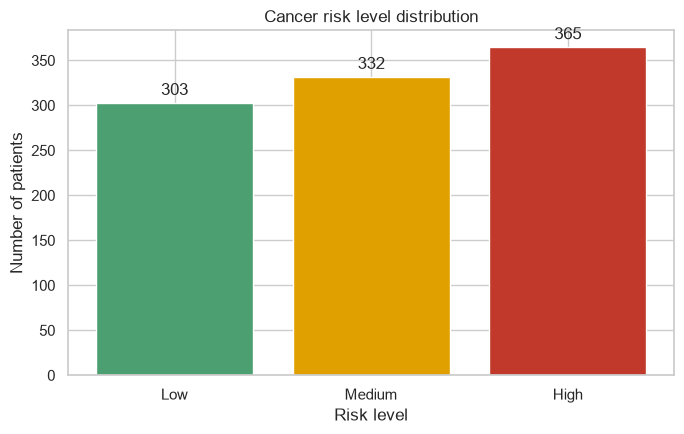

In [4]:
fig, ax = plt.subplots(figsize=(7, 4.5))
counts = df[TARGET].value_counts().reindex(LEVEL_ORDER)
bars = ax.bar(counts.index, counts.values, color=[LEVEL_COLORS[k] for k in counts.index])
ax.bar_label(bars, padding=3)
ax.set_title("Cancer risk level distribution")
ax.set_xlabel("Risk level")
ax.set_ylabel("Number of patients")
save_fig("01_target_distribution.png")
plt.show()

## 4. Age and gender

Age overlaps a lot across Low, Medium, and High, so age alone is a weak predictor. Gender 1 is more common than gender 2. The source file encodes gender as 1/2, not male/female labels.

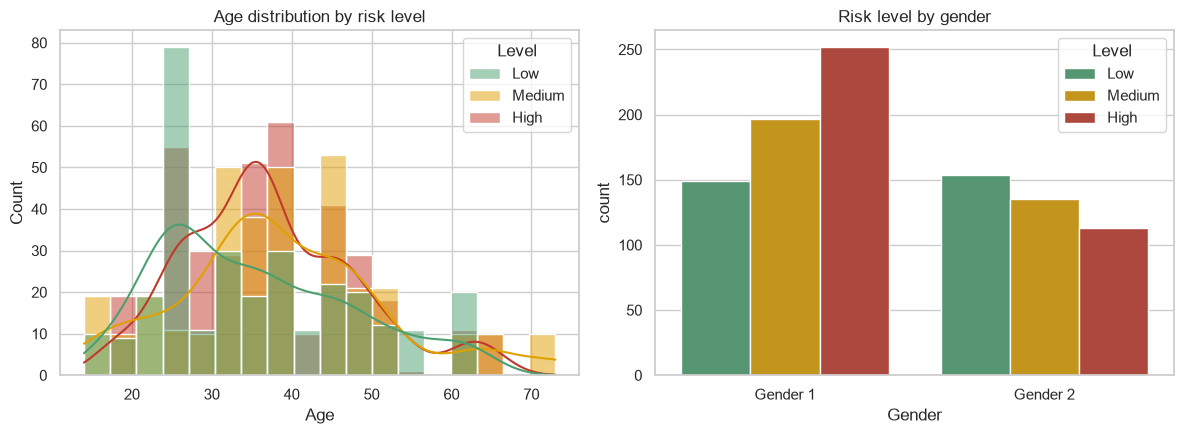

In [5]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))
sns.histplot(
    data=df, x="Age", hue=TARGET, hue_order=LEVEL_ORDER,
    palette=LEVEL_COLORS, ax=axes[0], kde=True,
)
axes[0].set_title("Age distribution by risk level")

gender_df = df.assign(GenderLabel=df["Gender"].map({1: "Gender 1", 2: "Gender 2"}))
sns.countplot(
    data=gender_df, x="GenderLabel", hue=TARGET,
    hue_order=LEVEL_ORDER, palette=LEVEL_COLORS, ax=axes[1],
)
axes[1].set_title("Risk level by gender")
axes[1].set_xlabel("Gender")
save_fig("02_age_gender.png")
plt.show()

## 5. Key risk factors

These boxplots are the most useful view. If a feature's median rises from Low to High, a model can use that gradient.

Smoking, obesity, genetic risk, alcohol use, occupational hazards, and several respiratory symptoms show that pattern. Those are the scores worth keeping for training.

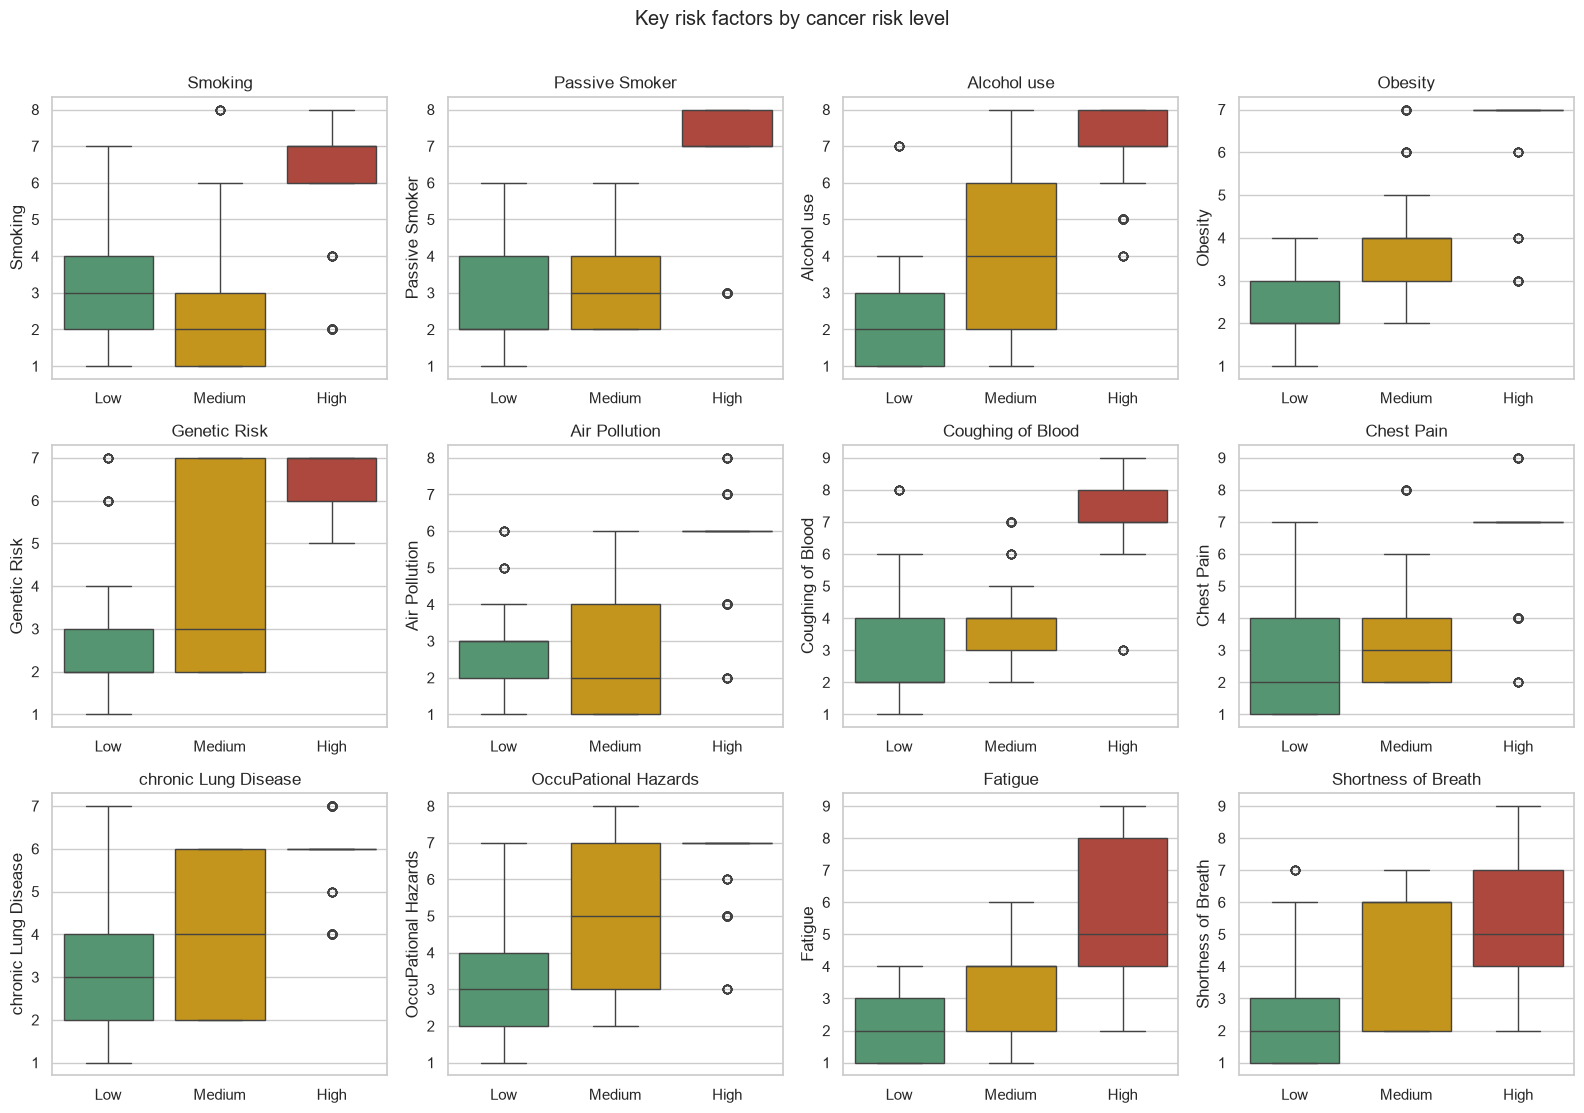

In [6]:
fig, axes = plt.subplots(3, 4, figsize=(16, 11))
for ax, col in zip(axes.ravel(), KEY_FEATURES):
    sns.boxplot(
        data=df, x=TARGET, y=col, order=LEVEL_ORDER,
        hue=TARGET, hue_order=LEVEL_ORDER, palette=LEVEL_COLORS,
        ax=ax, legend=False,
    )
    ax.set_title(col)
    ax.set_xlabel("")
fig.suptitle("Key risk factors by cancer risk level", y=1.01)
save_fig("04_feature_boxplots.png")
plt.tight_layout()
plt.show()

## 6. Feature correlations

Several lifestyle and exposure scores move together (smoking, alcohol use, occupational hazards, genetic risk). That multicollinearity can make a linear model less stable. A tree model can still use correlated features without assuming independence.

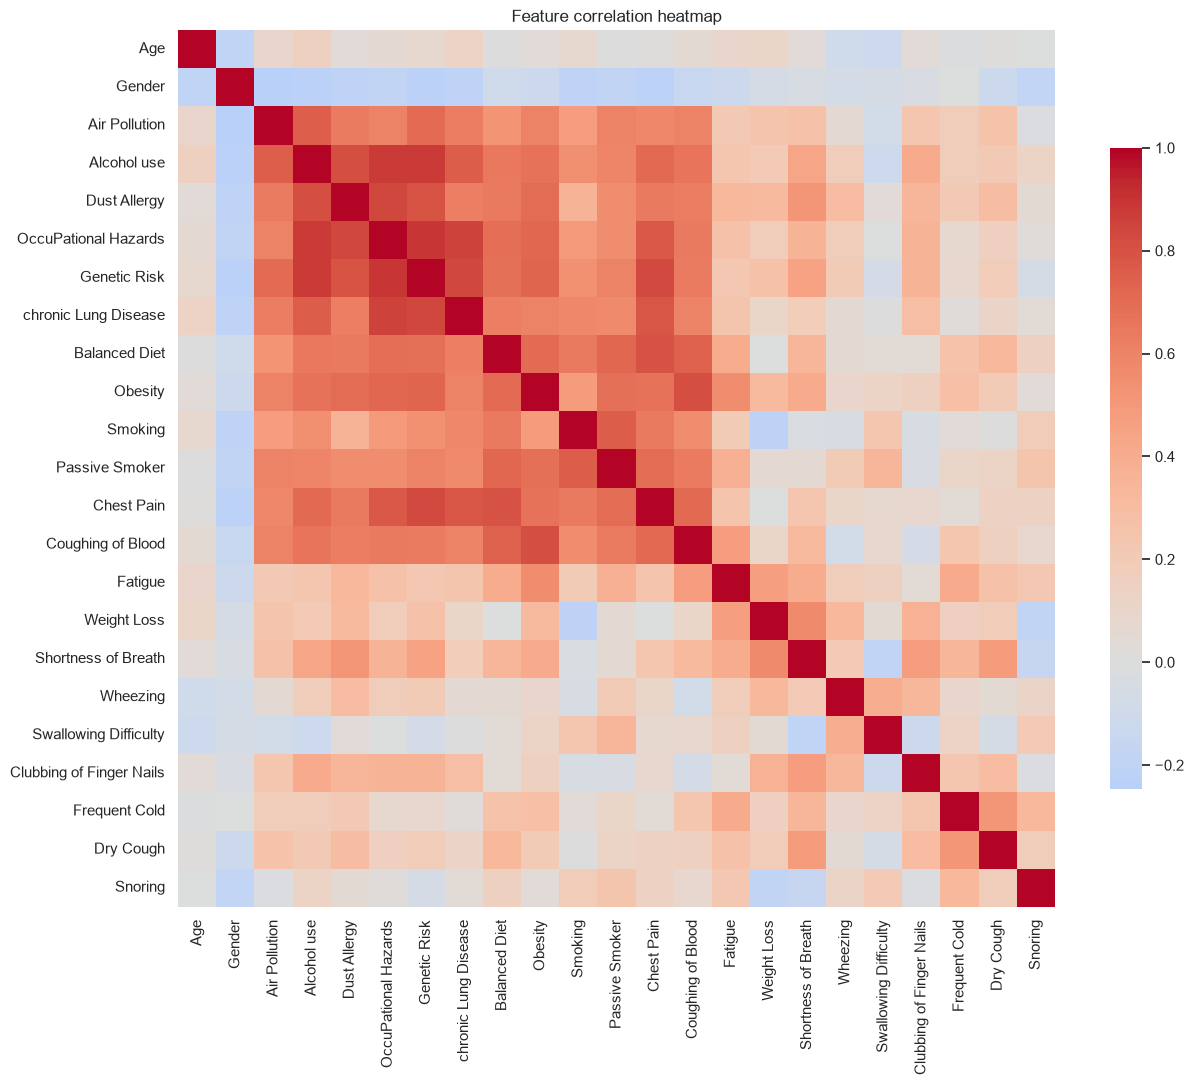

In [7]:
fig, ax = plt.subplots(figsize=(13, 11))
sns.heatmap(
    df[feature_cols].corr(numeric_only=True),
    cmap="coolwarm", center=0, ax=ax, square=True,
    cbar_kws={"shrink": 0.7},
)
ax.set_title("Feature correlation heatmap")
save_fig("03_correlation_heatmap.png")
plt.show()

## 7. EDA takeaways for modeling

- Drop `index` and `Patient Id`.
- Keep all 23 remaining scores as numeric features.
- Treat `Level` as a three-class classification problem, not a regression target.
- Prefer a tree model (Random Forest) as the default because features are correlated and the decision boundary is a profile-to-label mapping.
- Expect very high scores on this file because there are only 152 unique profiles.

Next step: run `python train.py` or open `main.ipynb` to train and evaluate the model.